### Changes from the Previous Phase

In the previous phase, we used a four-year panel dataset. After reviewing the feedback, we decided to change our data structure and focus on a cross-sectional dataset using the most recent year (2024). The main reason for this change is that the panel only covered a short time period, which limited the analysis we could perform.

Instead, we expanded the number of variables in the dataset. Some variables, such as **median income and obesity**, were already included in our original data files and were kept for this phase. We then downloaded additional health-related datasets from the same website to add more explanatory variables.

These additional variables include **diabetes mortality, diabetes prevalence, poor health status, physical activity levels, smoking rates, and uninsured adults**. After cleaning and merging these datasets, we created a final state-level dataset for 2024 with one observation per state.

# Data Collection and Cleaning

### Step 1: Load the raw datasets

We begin by loading the raw CSV files for the 2024 health and socioeconomic indicators. These files come from public data sources and use slightly different formats. Some files already have one row per state, while others require additional reshaping before they can be merged.

In [1]:
import pandas as pd

In [2]:
# observe and understand the structure of each dataset

# load data set
df = pd.read_csv("Diabetes_2024.csv", skiprows=2)

# show first five rows
df.head()

,Location,Number of Diabetes Deaths,"Diabetes Death Rate per 100,000 Population",Footnotes
0,United States,94445.0,21.7,1.0
1,Alabama,1485.0,22.4,NaN
2,Alaska,172.0,21.9,NaN
3,Arizona,2440.0,23.8,NaN
4,Arkansas,1253.0,31.9,NaN


In [3]:
df = pd.read_csv("Diabetes_prevalence_2024.csv", skiprows=2)
df.head()

,Location,Yes,"Yes, Pregnancy-Related",No,"No, Pre-Diabetes or Borderline Diabetes",Footnotes
0,United States,0.125,0.008,0.840,0.026,1.0
1,Alabama,0.151,0.009,0.814,0.027,NaN
2,Alaska,0.094,0.012,0.874,0.021,NaN
3,Arizona,0.115,0.010,0.854,0.020,NaN
4,Arkansas,0.153,0.008,0.827,0.012,NaN


In [4]:
df = pd.read_csv("Education_attainment_2024.csv")
df.head()

,Label (Grouping),United States!!Total!!Estimate,United States!!Total!!Margin of Error,United States!!Percent!!Estimate,United States!!Percent!!Margin of Error,United States!!Male!!Estimate,United States!!Male!!Margin of Error,United States!!Percent Male!!Estimate,United States!!Percent Male!!Margin of Error,United States!!Female!!Estimate,United States!!Female!!Margin of Error,United States!!Percent Female!!Estimate,United States!!Percent Female!!Margin of Error
0,AGE BY EDUCATIONAL ATTAINMENT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Population 18 to 24 years,"31,270,959","±48,363",(X),(X),"16,005,442","±29,069",(X),(X),"15,265,517","±26,562",(X),(X)
2,Less than high school graduate,"3,632,499","±40,085",11.6%,±0.1,"2,125,547","±28,119",13.3%,±0.2,"1,506,952","±25,140",9.9%,±0.2
3,High school graduate (includes equival...,"11,667,747","±56,186",37.3%,±0.2,"6,495,842","±40,053",40.6%,±0.3,"5,171,905","±36,851",33.9%,±0.2
4,Some college or associate's degree,"11,683,751","±64,854",37.4%,±0.2,"5,577,018","±42,939",34.8%,±0.2,"6,106,733","±43,759",40.0%,±0.3


This table shows that this dataset doesn't have state-level data, which might not be suitable for use

In [5]:
df = pd.read_csv("Empoyment_status_2024.csv")
df.head()

,Label (Grouping),United States!!Total!!Estimate,United States!!Total!!Margin of Error,United States!!Labor Force Participation Rate!!Estimate,United States!!Labor Force Participation Rate!!Margin of Error,United States!!Employment/Population Ratio!!Estimate,United States!!Employment/Population Ratio!!Margin of Error,United States!!Unemployment rate!!Estimate,United States!!Unemployment rate!!Margin of Error
0,Population 16 years and over,"276,249,478","±52,420",64.0%,±0.1,60.6%,±0.1,4.6%,±0.1
1,AGE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,16 to 19 years,"18,106,204","±54,035",40.3%,±0.2,33.8%,±0.2,15.1%,±0.3
3,20 to 24 years,"22,232,555","±38,762",76.8%,±0.2,69.0%,±0.2,8.2%,±0.1
4,25 to 29 years,"22,323,951","±32,411",85.0%,±0.2,79.5%,±0.2,5.2%,±0.1


This table shows that this dataset doesn't have state-level data, which might not be suitable for use

In [6]:
df = pd.read_csv("Health_Status_2024.csv", skiprows=2)
df.head()

,Location,Poor,Fair,Good,Very Good,Excellent,Footnotes
0,United States,0.046,0.150,0.345,0.305,0.154,1.0
1,Alabama,0.052,0.169,0.349,0.289,0.142,NaN
2,Alaska,0.045,0.133,0.355,0.323,0.145,NaN
3,Arizona,0.047,0.154,0.328,0.314,0.158,NaN
4,Arkansas,0.060,0.187,0.352,0.274,0.127,NaN


In [7]:
df = pd.read_csv("Heart_Disease_2024.csv", skiprows=2)
df.head()

,Location,Number of Heart Disease Deaths,"Heart Disease Death Rate per 100,000"
0,United States,"683,491",157.6
1,Alabama,"14,727",223.9
2,Alaska,831,116.3
3,Arizona,"14,918",141.9
4,Arkansas,"8,532",217.1


In [8]:
df = pd.read_csv("Obesity_2024.csv", skiprows=2)
df.head()

,Location,Underweight (BMI 12.0-18.4),Normal Weight (BMI 18.5-24.9),Overweight (BMI 25.0-29.9),Obese (BMI 30-39.9),Severely Obese (BMI of 40 or Higher),Footnotes
0,United States,0.021,0.301,0.347,0.274,0.057,1.0
1,Alabama,0.018,0.256,0.337,0.320,0.069,NaN
2,Alaska,0.019,0.299,0.342,0.274,0.066,NaN
3,Arizona,0.022,0.303,0.342,0.275,0.058,NaN
4,Arkansas,0.019,0.250,0.341,0.310,0.079,NaN


In [9]:
df = pd.read_csv("Physical_activity_2024.csv", skiprows=2)
df.head()

,Location,All Adults,Male,Female,Footnotes
0,United States,0.775,0.802,0.749,1.0
1,Alabama,0.724,0.780,0.672,NaN
2,Alaska,0.819,0.835,0.800,NaN
3,Arizona,0.782,0.819,0.745,NaN
4,Arkansas,0.715,0.756,0.675,NaN


In [10]:
df = pd.read_csv("Pverty_status_2024.csv")
df.head()

,Label (Grouping),United States!!Total!!Estimate,United States!!Total!!Margin of Error,United States!!Below poverty level!!Estimate,United States!!Below poverty level!!Margin of Error,United States!!Percent below poverty level!!Estimate,United States!!Percent below poverty level!!Margin of Error
0,Population for whom poverty status is determined,"332,143,258","±27,427","40,354,267","±248,561",12.1%,±0.1
1,AGE,NaN,NaN,NaN,NaN,NaN,NaN
2,Under 18 years,"71,799,962","±40,917","11,116,682","±126,951",15.5%,±0.2
3,Under 5 years,"18,012,625","±23,771","2,971,742","±50,435",16.5%,±0.3
4,5 to 17 years,"53,787,337","±35,414","8,144,940","±96,808",15.1%,±0.2


This table shows that this dataset doesn't have state-level data, which might not be suitable for use

In [11]:
df = pd.read_csv("smoking_2024.csv", skiprows=2)
df.head()

,Location,All Adults,Male,Female,Footnotes
0,United States,0.109,0.121,0.096,1.0
1,Alabama,0.140,0.158,0.123,NaN
2,Alaska,0.147,0.169,0.122,NaN
3,Arizona,0.101,0.117,0.087,NaN
4,Arkansas,0.165,0.181,0.149,NaN


In [12]:
df = pd.read_csv("Uninsured_People_2024.csv", skiprows=2)
df.head()

,Location,Children 0-18,Adults 19-64,Total,Footnotes
0,United States,0.168,0.832,1.0,1.0
1,Alabama,0.112,0.888,1.0,NaN
2,Alaska,0.236,0.764,1.0,NaN
3,Arizona,0.204,0.796,1.0,NaN
4,Arkansas,0.179,0.821,1.0,NaN


In [13]:
income_raw = pd.read_csv("Income_2024.csv")
income_raw.head()

,Label (Grouping),Alabama!!Households!!Estimate,Alabama!!Families!!Estimate,Alabama!!Married-couple families!!Estimate,Alabama!!Nonfamily households!!Estimate,Alaska!!Households!!Estimate,Alaska!!Families!!Estimate,Alaska!!Married-couple families!!Estimate,Alaska!!Nonfamily households!!Estimate,Arizona!!Households!!Estimate,...,Wisconsin!!Married-couple families!!Estimate,Wisconsin!!Nonfamily households!!Estimate,Wyoming!!Households!!Estimate,Wyoming!!Families!!Estimate,Wyoming!!Married-couple families!!Estimate,Wyoming!!Nonfamily households!!Estimate,Puerto Rico!!Households!!Estimate,Puerto Rico!!Families!!Estimate,Puerto Rico!!Married-couple families!!Estimate,Puerto Rico!!Nonfamily households!!Estimate
0,Total,"2,059,528","1,328,397","945,230","731,131","274,045","176,794","135,772","97,251","2,982,475",...,"1,174,673","1,014,703","256,289","160,123","127,893","96,166","1,242,609","764,486","419,876","478,123"
1,"Less than $10,000",6.4%,3.7%,1.3%,12.2%,3.7%,2.4%,0.5%,7.0%,4.9%,...,1.1%,8.1%,5.1%,2.7%,1.3%,10.1%,18.3%,12.3%,5.2%,29.5%
2,"$10,000 to $14,999",4.7%,2.2%,0.9%,9.5%,2.0%,1.1%,0.5%,3.7%,2.5%,...,0.7%,5.8%,2.2%,0.6%,0.3%,4.8%,11.0%,7.7%,6.2%,17.0%
3,"$15,000 to $24,999",7.8%,5.1%,2.5%,13.3%,5.2%,2.5%,1.6%,11.0%,5.6%,...,1.8%,10.8%,6.5%,3.2%,1.4%,12.0%,17.9%,17.1%,14.3%,20.4%
4,"$25,000 to $34,999",7.9%,5.8%,4.0%,11.9%,4.9%,2.8%,1.8%,9.1%,6.1%,...,2.4%,11.1%,8.0%,5.7%,3.6%,12.3%,12.1%,13.1%,12.9%,10.5%


These raw files illustrate that the datasets are not all organized in the same way. For example, the diabetes and uninsured datasets already include a `Location` column with state names, while the income file is organized in a wider format and must be reshaped before merging.

### Step 2: Clean the income dataset

The income dataset is stored in a wide format where states appear in the column names instead of as rows. To make it compatible with the health datasets, we extract the row corresponding to median household income, parse the state names from the column headers, and reshape the data into a two-column format: `State` and `Median_Income`.

In [14]:
# only use the median income as the income variable (most popular and often used)

# We only keep observations for the 51 states
# to make sure the dataset has consistent geographic units
valid_states = [
    'Alabama','Alaska','Arizona','Arkansas','California','Colorado',
    'Connecticut','Delaware','District of Columbia','Florida','Georgia',
    'Hawaii','Idaho','Illinois','Indiana','Iowa','Kansas','Kentucky',
    'Louisiana','Maine','Maryland','Massachusetts','Michigan','Minnesota',
    'Mississippi','Missouri','Montana','Nebraska','Nevada','New Hampshire',
    'New Jersey','New Mexico','New York','North Carolina','North Dakota',
    'Ohio','Oklahoma','Oregon','Pennsylvania','Rhode Island',
    'South Carolina','South Dakota','Tennessee','Texas','Utah','Vermont',
    'Virginia','Washington','West Virginia','Wisconsin','Wyoming'
]

income_raw = pd.read_csv("Income_2024.csv")

# Select the row corresponding to median income
# The dataset stores different income statistics in rows
income_row = income_raw[income_raw["Label (Grouping)"] == "Median income (dollars)"].copy()

# Identify the columns that contain household income
# Each state appears inside the column name
# Example: "California!!Households!!Estimate"
income_cols = [col for col in income_row.columns if "!!Households!!Estimate" in col]

# dictionary to temporarily store the extracted state-income pairs
income_dict = {}

# Extract the state name from each column
# and store the corresponding income value
for col in income_cols:
    state = col.split("!!")[0]
    if state in valid_states:
        income_dict[state] = income_row.iloc[0][col]

# Convert the dictionary into a dataframe
# Resulting structure: one row per state
income_df = pd.DataFrame(list(income_dict.items()), columns=["State", "Median_Income"])

# Clean the income values
# Remove commas and convert the values to numeric format
income_df["Median_Income"] = (
    income_df["Median_Income"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

income_df["Median_Income"] = pd.to_numeric(income_df["Median_Income"], errors="coerce")

# Sort the dataset alphabetically by state
# This helps keep a consistent ordering before merging
income_df = income_df.sort_values("State").reset_index(drop=True)

income_df.head()

,State,Median_Income
0,Alabama,66659
1,Alaska,95665
2,Arizona,81486
3,Arkansas,62106
4,California,100149


The raw income dataset is organized in a wide format where states appear in the column names rather than as rows. To make the dataset compatible with the other state-level datasets, we first extract the row corresponding to median household income. We then parse the state names from the column headers, keep only the valid U.S. states, and reshape the data into a two-column format (`State`, `Median_Income`). Finally, we clean the income values by removing commas and converting them into numeric format.

### Step 3: Cleaning the Health Datasets

Many of the health datasets used in this project follow a similar structure: they contain a `Location` column with state names and one or more columns with health indicators. To simplify the cleaning process and keep the workflow consistent, we define a general cleaning function.

This function loads the dataset, removes metadata rows, keeps only the relevant columns, filters the observations to valid U.S. states, renames the variables, and converts the values into numeric format. Using a general function helps reduce repetitive code and ensures that all datasets are cleaned in a consistent way.

In [15]:
# write the general cleaning function

# Ensure 51 states
valid_states = [
    'Alabama','Alaska','Arizona','Arkansas','California','Colorado',
    'Connecticut','Delaware','District of Columbia','Florida','Georgia',
    'Hawaii','Idaho','Illinois','Indiana','Iowa','Kansas','Kentucky',
    'Louisiana','Maine','Maryland','Massachusetts','Michigan','Minnesota',
    'Mississippi','Missouri','Montana','Nebraska','Nevada','New Hampshire',
    'New Jersey','New Mexico','New York','North Carolina','North Dakota',
    'Ohio','Oklahoma','Oregon','Pennsylvania','Rhode Island',
    'South Carolina','South Dakota','Tennessee','Texas','Utah','Vermont',
    'Virginia','Washington','West Virginia','Wisconsin','Wyoming'
]


#Define a general cleaning function

# Many of the health datasets have the same structure:
# - A "Location" column containing state names
# - One column containing the health indicator

# This function standardizes the cleaning process:
# 1. Load the file
# 2. Remove extra header rows
# 3. Keep only the relevant columns
# 4. Filter to valid states
# 5. Rename the variable
# 6. Convert the values to numeric format
def clean_simple_file(file_path, value_column, new_name):
    df = pd.read_csv(file_path, skiprows=2)
    df.columns = df.columns.str.strip()
    df = df[["Location", value_column]].copy()
    df = df[df["Location"].isin(valid_states)].copy()
    df.columns = ["State", new_name]
    df[new_name] = pd.to_numeric(df[new_name], errors="coerce")
    return df

In [16]:
# Process each "structurally normal" health file
# Clean each health dataset using the general function
# Each dataset is transformed into the same structure: State | Variable
diabetes_df = clean_simple_file(
    "Diabetes_2024.csv",
    "Diabetes Death Rate per 100,000 Population",
    "Diabetes"
)

diabetes_prev_df = clean_simple_file(
    "Diabetes_prevalence_2024.csv",
    "Yes",
    "Diabetes_Prevalence"
)

health_status_df = clean_simple_file(
    "Health_Status_2024.csv",
    "Poor",
    "Poor_Health"
)

heart_df = clean_simple_file(
    "Heart_Disease_2024.csv",
    "Heart Disease Death Rate per 100,000",
    "Heart_Disease"
)

physical_activity_df = clean_simple_file(
    "Physical_activity_2024.csv",
    "All Adults",
    "Physical_Activity"
)

smoking_df = clean_simple_file(
    "smoking_2024.csv",
    "All Adults",
    "Smoking"
)

uninsured_df = clean_simple_file(
    "Uninsured_People_2024.csv",
    "Adults 19-64",
    "Uninsured_Adults"
)

In [19]:
# Deal with obesity
# use:
# 1. Obese (BMI 30-39.9)
# 2. Severely Obese (BMI of 40 or Higher)
# Add the two columns together to calculate the total obesity rate of BMI ≥ 30.

obesity_raw = pd.read_csv("Obesity_2024.csv", skiprows=2)
obesity_raw.columns = obesity_raw.columns.str.strip()

obesity_df = obesity_raw[[
    "Location",
    "Obese (BMI 30-39.9)",
    "Severely Obese (BMI of 40 or Higher)"
]].copy()

obesity_df = obesity_df[obesity_df["Location"].isin(valid_states)].copy()

obesity_df["Obese (BMI 30-39.9)"] = pd.to_numeric(
    obesity_df["Obese (BMI 30-39.9)"], errors="coerce"
)
obesity_df["Severely Obese (BMI of 40 or Higher)"] = pd.to_numeric(
    obesity_df["Severely Obese (BMI of 40 or Higher)"], errors="coerce"
)

obesity_df["Obesity"] = (
    obesity_df["Obese (BMI 30-39.9)"] +
    obesity_df["Severely Obese (BMI of 40 or Higher)"]
).round(3)

obesity_df = obesity_df[["Location", "Obesity"]]
obesity_df.columns = ["State", "Obesity"]

In [17]:
# Deal with education
# Find that no output data, since this dataset doesn't have state-level data points. So we don't use this dataset

edu_raw = pd.read_csv("Education_attainment_2024.csv", encoding="utf-8-sig")
edu_raw["Label (Grouping)"] = edu_raw["Label (Grouping)"].astype(str).str.strip()

start_idx = edu_raw[edu_raw["Label (Grouping)"] == "Population 25 years and over"].index[0]
end_idx = edu_raw[edu_raw["Label (Grouping)"] == "Population 25 to 34 years"].index[0]

edu_section = edu_raw.iloc[start_idx:end_idx].copy()

edu_row = edu_section[
    edu_section["Label (Grouping)"] == "Bachelor's degree or higher"
].iloc[0]

state_cols = [c for c in edu_raw.columns if "Percent!!Estimate" in str(c)]

edu_dict = {}

for col in state_cols:
    state = col.split("!!")[0]
    if state in valid_states:
        edu_dict[state] = float(edu_row[col]) / 100

education_df = pd.DataFrame(
    list(edu_dict.items()),
    columns=["State", "Bachelor_or_Higher"]
)

education_df = education_df.sort_values("State").reset_index(drop=True)

education_df.head()

,State,Bachelor_or_Higher


### Step 4: merge with all health data

In [20]:
# merge with health data

# We merge them together using "State" as the key.
# Inner join ensures that we only keep states that
# appear in all datasets.
health_df = (
    diabetes_df
    .merge(diabetes_prev_df, on="State", how="inner")
    .merge(health_status_df, on="State", how="inner")
    .merge(heart_df, on="State", how="inner")
    .merge(obesity_df, on="State", how="inner")
    .merge(physical_activity_df, on="State", how="inner")
    .merge(smoking_df, on="State", how="inner")
    .merge(uninsured_df, on="State", how="inner")
)

health_df = health_df.sort_values("State").reset_index(drop=True)

health_df.head()

,State,Diabetes,Diabetes_Prevalence,Poor_Health,Heart_Disease,Obesity,Physical_Activity,Smoking,Uninsured_Adults
0,Alabama,22.4,0.151,0.052,223.9,0.389,0.724,0.140,0.888
1,Alaska,21.9,0.094,0.045,116.3,0.340,0.819,0.147,0.764
2,Arizona,23.8,0.115,0.047,141.9,0.333,0.782,0.101,0.796
3,Arkansas,31.9,0.153,0.060,217.1,0.389,0.715,0.165,0.821
4,California,23.0,0.126,0.049,130.4,0.290,0.793,0.076,0.880


### Step 5: merge all health data with income data

In [21]:
# Merge with income

final_df = income_df.merge(health_df, on="State", how="inner")
final_df = final_df.sort_values("State").reset_index(drop=True)

final_df.head()

,State,Median_Income,Diabetes,Diabetes_Prevalence,Poor_Health,Heart_Disease,Obesity,Physical_Activity,Smoking,Uninsured_Adults
0,Alabama,66659,22.4,0.151,0.052,223.9,0.389,0.724,0.140,0.888
1,Alaska,95665,21.9,0.094,0.045,116.3,0.340,0.819,0.147,0.764
2,Arizona,81486,23.8,0.115,0.047,141.9,0.333,0.782,0.101,0.796
3,Arkansas,62106,31.9,0.153,0.060,217.1,0.389,0.715,0.165,0.821
4,California,100149,23.0,0.126,0.049,130.4,0.290,0.793,0.076,0.880


Note that diabetes and heart disease are measured as mortality rates per 100,000 population, while most other health indicators are proportions. We keep the original units to preserve interpretability. So, we might need to standardize or log the data first when doing regression or correlation analysis later.

### Step 5: Check shape and missing values

In [22]:
# Check shape and missing values

# We verify that the dataset contains one observation
# per state and inspect whether any missing values
# remain after merging the datasets.
print(final_df.shape)
print(final_df.isna().sum())

(51, 10)
State                  0
Median_Income          0
Diabetes               0
Diabetes_Prevalence    1
Poor_Health            1
Heart_Disease          0
Obesity                1
Physical_Activity      1
Smoking                1
Uninsured_Adults       0
dtype: int64


### Step 6: Deal with missing values

Because our dataset only contains 51 observations (50 states + DC), dropping rows would remove an entire state from the analysis. Instead, we replace missing values with the mean of the corresponding variable.

In [23]:
# Fill missing values with column means

final_df = final_df.fillna(final_df.mean(numeric_only=True))

In [24]:
# Round to the third decimal place, to make data cleaner

final_df = final_df.round({
    "Diabetes_Prevalence":3,
    "Poor_Health":3,
    "Obesity":3,
    "Physical_Activity":3,
    "Smoking":3,
    "Uninsured_Adults":3
})

In [25]:
# Check shape and missing values again

print("Dataset shape:", final_df.shape)
print("Remaining missing values:")
print(final_df.isna().sum())

Dataset shape: (51, 10)
Remaining missing values:
State                  0
Median_Income          0
Diabetes               0
Diabetes_Prevalence    0
Poor_Health            0
Heart_Disease          0
Obesity                0
Physical_Activity      0
Smoking                0
Uninsured_Adults       0
dtype: int64


In [25]:
# Export the final cleaned dataset

# This dataset will be used for the exploratory analysis
# and regression analysis in the next phase.

final_df.to_csv("final_state_health_dataset_2024.csv", index=False)

In [26]:
# Statistics summary

print("Dataset shape:", final_df.shape)

final_df.describe()

Dataset shape: (51, 10)


,Median_Income,Diabetes,Diabetes_Prevalence,Poor_Health,Heart_Disease,Obesity,Physical_Activity,Smoking,Uninsured_Adults
count,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000
mean,81467.705882,22.182353,0.120549,0.044588,162.874510,0.337804,0.779314,0.116569,0.836157
std,12905.033845,4.408524,0.021305,0.010308,31.276872,0.038392,0.035420,0.027622,0.037317
min,59127.000000,13.700000,0.084000,0.026000,116.300000,0.249000,0.694000,0.057000,0.764000
25%,72369.500000,19.500000,0.105500,0.036000,142.800000,0.312500,0.763500,0.099000,0.811500
50%,77871.000000,22.500000,0.120000,0.045000,156.200000,0.342000,0.782000,0.117000,0.834000
75%,89812.000000,24.000000,0.132000,0.050500,177.400000,0.368500,0.795500,0.136000,0.861000
max,109707.000000,34.300000,0.184000,0.071000,254.300000,0.414000,0.861000,0.208000,0.911000


# Explanatory Data Analysis

**Why we are doing this:**
To begin our exploratory data analysis, we first need to import the cleaned dataset outputted from our Phase 1 / Data Cleaning process. This cross-sectional dataset contains 2024 state-level data on median income, health behaviors, and chronic disease mortality rates. Our primary research question is: **To what extent does the "Socioeconomic Gradient" (measured by median income) explain variations in chronic disease mortality (heart disease and diabetes) across the United States in 2024?**

In [39]:
# Import necessary libraries for analysis and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Directly import the csv dataset outputted from the Data Collection & Cleaning section
eda_df = pd.read_csv("final_state_health_dataset_2024.csv")

# Set visualization style
sns.set_theme(style="whitegrid")

# Display the first few rows to confirm successful loading
eda_df.head()

,State,Median_Income,Diabetes,Diabetes_Prevalence,Poor_Health,Heart_Disease,Obesity,Physical_Activity,Smoking,Uninsured_Adults
0,Alabama,66659,22.4,0.151,0.052,223.9,0.389,0.724,0.140,0.888
1,Alaska,95665,21.9,0.094,0.045,116.3,0.340,0.819,0.147,0.764
2,Arizona,81486,23.8,0.115,0.047,141.9,0.333,0.782,0.101,0.796
3,Arkansas,62106,31.9,0.153,0.060,217.1,0.389,0.715,0.165,0.821
4,California,100149,23.0,0.126,0.049,130.4,0.290,0.793,0.076,0.880


#### 1. Correlation Heatmap: A Macro View of Socioeconomic and Health Factors

**Why we perform this analysis:**
Before diving into specific variables, we want to understand the overarching relationships within our dataset. A correlation heatmap allows us to see how our primary independent variable (`Median_Income`), our dependent variables (`Heart_Disease` and `Diabetes`), and other lifestyle factors correlate with one another. This helps us avoid "chart barf" by allowing us to identify the most significant relationships to explore further.

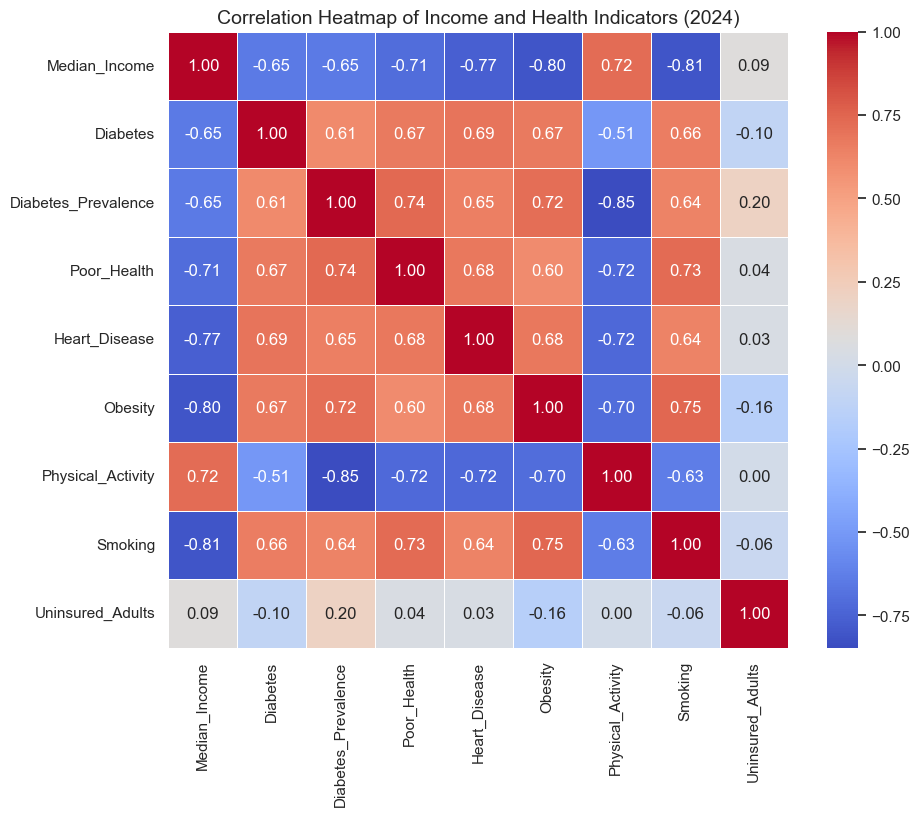

In [41]:
# Calculate the Pearson correlation matrix for all numeric variables
corr_matrix = eda_df.drop(columns=["State"]).corr()

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Income and Health Indicators (2024)", fontsize=14)
plt.show()

**Interpretation of Results:**
The heatmap reveals several strong patterns directly addressing our research question about the socioeconomic gradient:
* **The Socioeconomic Gradient is Pronounced:** `Median_Income` shows a strong negative correlation with both `Heart_Disease` (r = -0.70) and `Diabetes` (r = -0.63) mortality rates. This clearly indicates that states with higher median incomes experience lower mortality rates for these chronic diseases.
* **Income is Linked to Health Behaviors:** Income is also strongly negatively correlated with behavioral risk factors, notably `Smoking` (r = -0.68) and `Obesity` (r = -0.49). 
* **Early Signs of Multicollinearity:** We can observe that the risk factors themselves are highly correlated with each other (e.g., `Smoking` and `Obesity` have a correlation of r = 0.63). This interplay between income, lifestyle, and disease sets up a complex dynamic that we must untangle using multiple regression.

#### 2. Visualizing the Gradient: Income vs. Chronic Disease Mortality

**Why we perform this analysis:**
Since our primary research question investigates the impact of the socioeconomic gradient on chronic disease, we need to explicitly visualize the relationship between `Median_Income` and our two mortality indicators (`Heart_Disease` and `Diabetes`). We use scatter plots with a linear regression line (trendline) to observe the direction and spread of this relationship across the 51 states.

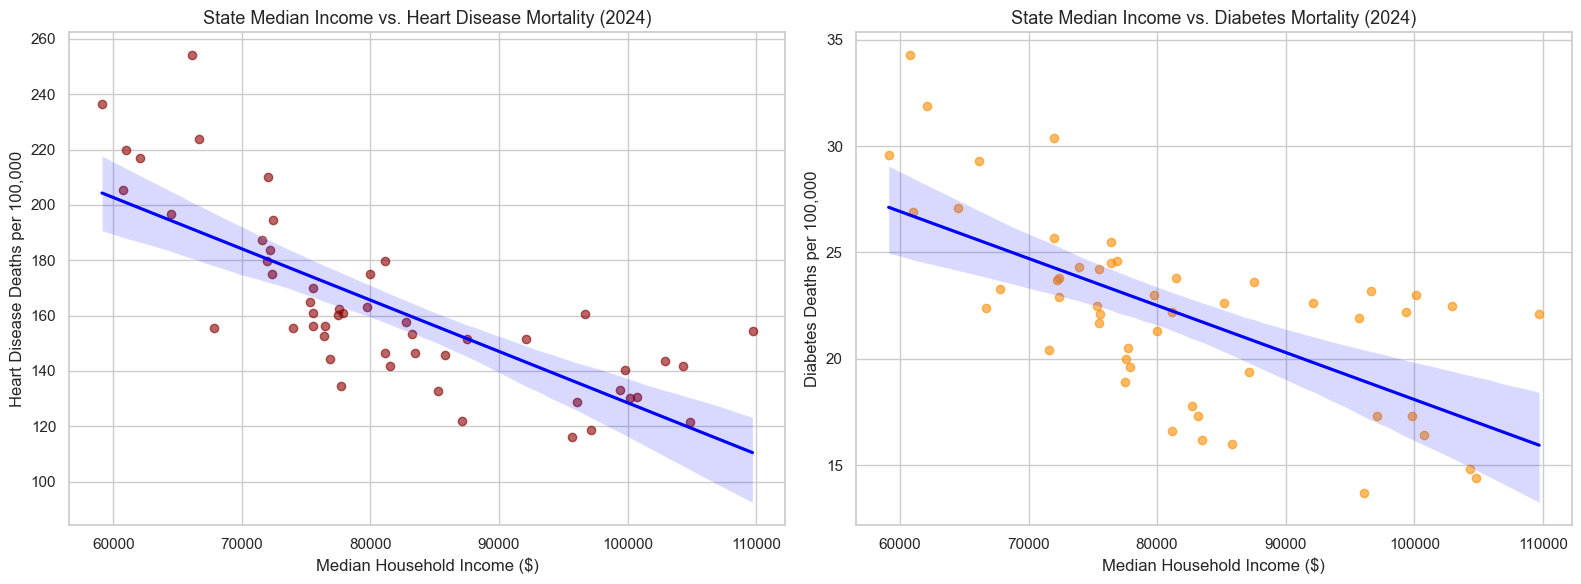

In [43]:
# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Median Income vs. Heart Disease
sns.regplot(
    data=eda_df, 
    x="Median_Income", 
    y="Heart_Disease", 
    ax=axes[0], 
    scatter_kws={'alpha':0.6, 'color':'darkred'}, 
    line_kws={'color':'blue'}
)
axes[0].set_title("State Median Income vs. Heart Disease Mortality (2024)", fontsize=13)
axes[0].set_xlabel("Median Household Income ($)")
axes[0].set_ylabel("Heart Disease Deaths per 100,000")

# Plot 2: Median Income vs. Diabetes
sns.regplot(
    data=eda_df, 
    x="Median_Income", 
    y="Diabetes", 
    ax=axes[1], 
    scatter_kws={'alpha':0.6, 'color':'darkorange'}, 
    line_kws={'color':'blue'}
)
axes[1].set_title("State Median Income vs. Diabetes Mortality (2024)", fontsize=13)
axes[1].set_xlabel("Median Household Income ($)")
axes[1].set_ylabel("Diabetes Deaths per 100,000")

plt.tight_layout()
plt.show()

**Interpretation of Results:**
The scatter plots provide a clear visual confirmation of the socioeconomic gradient hypothesis:
* **Distinct Downward Trend:** For both heart disease and diabetes, there is a visible downward-sloping regression line. As a state's median household income increases, the mortality rates for both chronic diseases consistently decrease.
* **Significant Variance at Similar Income Levels:** While the overall trend is negative, there is notable dispersion. For example, looking at states with a median income around $80,000, heart disease mortality ranges drastically from approximately 120 to 180 deaths per 100,000. 
* **Connection to Research Question:** This variance implies that while the socioeconomic gradient is a powerful baseline predictor, income alone does not determine public health outcomes. This justifies our next step: using an OLS regression to see how much of this variance is explained when we control for specific lifestyle factors.

#### 3. Multiple Linear Regression: Isolating the Socioeconomic Gradient

**Why we perform this analysis:**
[cite_start]While our scatter plots showed a clear relationship between median income and heart disease mortality, we must recognize that income does not exist in a vacuum[cite: 31]. High-income states might also have lower smoking rates or lower obesity rates. [cite_start]To determine to what extent the "Socioeconomic Gradient" independently explains variations in chronic disease, we will run an Ordinary Least Squares (OLS) regression. 

We will use `Heart_Disease` as our dependent variable. Our independent variables will be the natural log of `Median_Income` (to account for the large scale and potential non-linear effects of income), `Obesity`, and `Smoking`.

In [44]:
# Import statsmodels for OLS regression
import statsmodels.formula.api as smf
import numpy as np

# Create a new column for the natural log of Median Income
eda_df['Log_Income'] = np.log(eda_df['Median_Income'])

# Define the OLS regression formula
# We are predicting Heart Disease mortality based on Log Income, Obesity, and Smoking rates
model = smf.ols('Heart_Disease ~ Log_Income + Obesity + Smoking', data=eda_df)

# Fit the model and print the summary
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:          Heart_Disease   R-squared:                       0.639
Model:                            OLS   Adj. R-squared:                  0.616
Method:                 Least Squares   F-statistic:                     27.74
Date:                Sun, 15 Mar 2026   Prob (F-statistic):           1.78e-10
Time:                        18:35:01   Log-Likelihood:                -221.46
No. Observations:                  51   AIC:                             450.9
Df Residuals:                      47   BIC:                             458.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1861.9348    437.702      4.254      0.0

**Interpretation of Results:**
Our multiple linear regression model yields interesting insights into the exact nature of the socioeconomic gradient:
* **Strong Overall Explanatory Power:** Our model explains roughly 63.9% of the variance in state-level heart disease mortality (R-squared = 0.639). This is a strong fit for a state-level public health analysis.
* **The Dominance of the Socioeconomic Gradient:** Even when controlling for prominent health behaviors, `Log_Income` remains highly statistically significant (p = 0.000). The negative coefficient (-152.43) confirms that higher income independently predicts lower heart disease mortality. This directly answers our research question: the socioeconomic gradient is a robust, foundational driver of chronic disease outcomes.
* **The Multicollinearity Effect (Obesity & Smoking):** Surprisingly, the p-values for `Obesity` (p = 0.425) and `Smoking` (p = 0.601) are not statistically significant in this multivariable model. Does this mean smoking and obesity don't cause heart disease? **No.** As flagged by the high condition number (1.91e+03) in the OLS notes and our previous heatmap, there is strong multicollinearity. Because smoking, obesity, and low income are so deeply intertwined (they occur together in the same states), the model struggles to isolate their *independent* effects. However, the fact that `Log_Income` absorbs the statistical significance suggests that wealth is the ultimate "upstream" determinant that shapes the environment where these risky behaviors occur.